# Filtre de Purcell réalisé à l’aide d’un résonateur demi-onde

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
from IPython.display import Image, display
from scipy.optimize import curve_fit
import scipy.constants as sc
path_fig="..//Figures/"
path_Sonnet="..//Sonnet/"

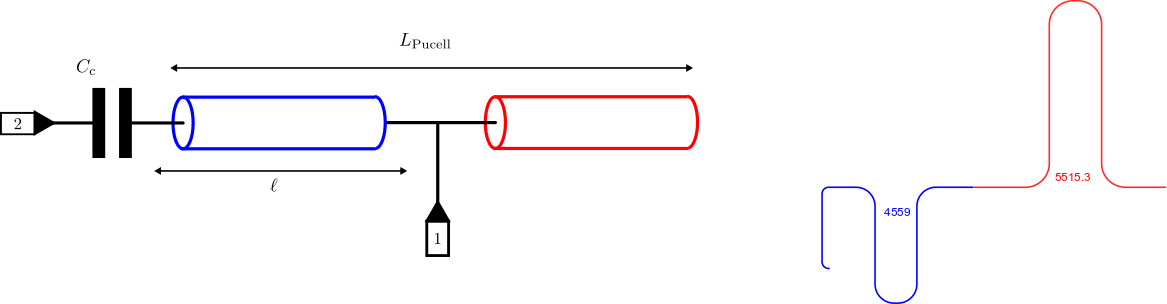

In [5]:
Image(filename=path_fig+"Purcell.png", width=900)

On cherche à simuler le filtre Purcell ci-dessus. La longueur totale du résonateur $\lambda/2$ est $L_{\mathrm{Purcell}}= 10.074 \, \mathrm{mm}$ et la capacité de couplage $C_{\mathrm{c}}= 1 \, \mathrm{nF}$ (voir ci-dessous). 

- Crée des lignes de transmission skrf définies par une longeur $L_{\mathrm{Purcell}}-\ell$ et $\ell$, une impédance caractéristique $Z_0= 54.93 \Omega$ et une vitesse de propagation $v=1.26 \times 10^8 \, \mathrm{m.s}^{-1}$ en vous aidant de l'exemple ci-dessous:

        s_line = np.zeros((Nf, 2, 2), dtype=complex)

        s_line[:, 0, 1] = np.exp(-1j * 2 * np.pi * f / c * L)

        s_line[:, 1, 0] = np.exp(-1j * 2 * np.pi * f / c * L)

        CPW= rf.Network(frequency=freq, s=s_line, z0=50, name='CPW_a_b')

- Créer 2 [ports](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Port.html), un [open](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.Open.html) et un [élément de circuit discret simulant la capacité](https://scikit-rf.readthedocs.io/en/latest/examples/circuit/Lumped%20Element%20Circuits.html) $C_c$  
- Créer des [connexions](https://scikit-rf.readthedocs.io/en/latest/api/generated/skrf.circuit.Circuit.connections_list.html) simulant le circuit ci-dessus pour différentes valeur de $\ell$.

In [47]:

L=100742e-6
p=(993+3493)/(993+3493+5437)
l=L*np.concatenate([np.linspace(0.4,0.6,5), [p]])
Param=['40 %','45 %','50 %','55 %','60 %','exp.']
Cc=1e-12
Zc=54.93
v=1.26e8
Nf=10000
freq=rf.Frequency(4, 8, Nf, unit='ghz')

In [48]:
CPWa = []
CPWb = []

for i in range(0,len(l)):
    s_line_a = np.zeros((Nf, 2, 2), dtype=complex)
    s_line_a[:, 0, 1] = np.exp(-1j * 2 * np.pi * freq.f / v * l[i])
    s_line_a[:, 1, 0] = np.exp(-1j * 2 * np.pi * freq.f  / v * l[i])
    cpwa= rf.Network(frequency=freq, s=s_line_a, z0=Zc, name='CPWa_'+str(i))
    CPWa.append(cpwa)
    s_line_b = np.zeros((Nf, 2, 2), dtype=complex)
    s_line_b[:, 0, 1] = np.exp(-1j * 2 * np.pi * freq.f  / v * (L-l[i]))
    s_line_b[:, 1, 0] = np.exp(-1j * 2 * np.pi * freq.f  / v * (L-l[i]))
    cpwb= rf.Network(frequency=freq, s=s_line_b, z0=Zc, name='CPWb_'+str(i))
    CPWb.append(cpwb)    


In [49]:
port1 = rf.Circuit.Port(frequency=freq, name='port1', z0=50)
port2 = rf.Circuit.Port(frequency=freq, name='port2', z0=50)
capa = rf.Circuit.SeriesImpedance(frequency=freq, name='capa', z0=Zc, Z=1/(1j*2*np.pi*freq.f*Cc))
Open = rf.Circuit.Open(freq, name='Open', z0=Zc)

In [50]:
connexion=[]
for k in range(len(l)):
    connexion.append([[(port1, 0), (CPWa[k], 0),(CPWb[k],1)],
                      [(CPWa[k],1), (Open,0)],
                      [(capa,1),(CPWb[k],0)],
                      [(port2, 0), (capa,0)],
                      ])


In [51]:
rf.Circuit(connexion[0])

<Figure size 640x480 with 0 Axes>

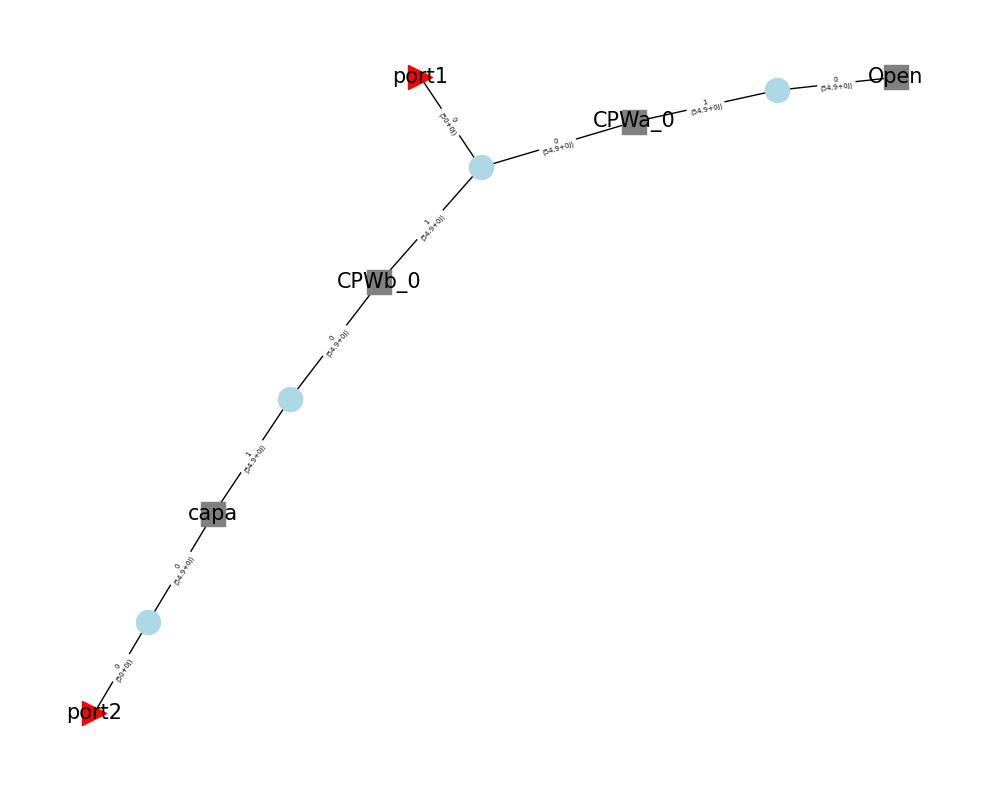

In [52]:
resulting_Circuit=[]
for k in range(len(l)):
    resulting_Circuit.append(rf.Circuit(connexion[k]))
plt.figure()
resulting_Circuit[0].plot_graph(network_labels=True, network_fontsize=15,
               port_labels=True, port_fontsize=15,
              edge_labels=True, edge_fontsize=5)
plt.show()

In [53]:
for k in range(4):
    print(resulting_Circuit[0].port_indexes)


[0, 7]
[0, 7]
[0, 7]
[0, 7]


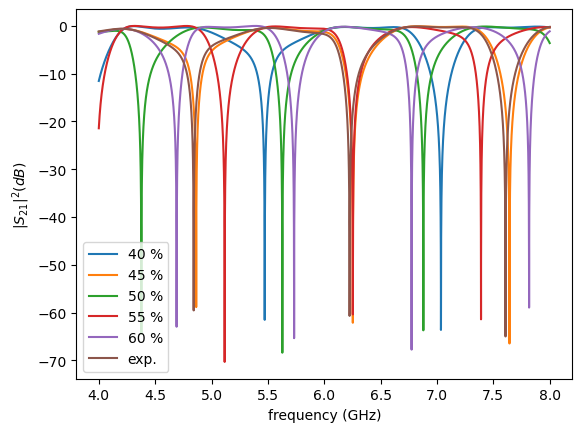

In [54]:
S21_Purcell=[]
plt.figure()
for k in range(len(l)):
    S21_Purcell.append(resulting_Circuit[k].s[:,7,0])
    plt.plot(1e-9*(resulting_Circuit[k].frequency.f),20*np.log10(np.abs(S21_Purcell[k])), label=Param[k])
plt.xlabel("frequency (GHz)")
plt.ylabel("$|S_{21}|^2 (dB)$")
plt.savefig(path_fig+'S21_Purcell.svg')
plt.legend()
#plt.xlim(6.18,6.22)
plt.show()

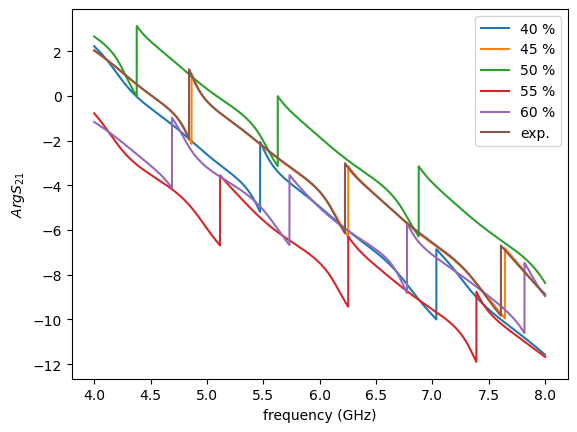

In [55]:
S21_Purcell=[]
plt.figure()
for k in range(len(l)):
    S21_Purcell.append(resulting_Circuit[k].s[:,7,0])
    plt.plot(1e-9*(resulting_Circuit[k].frequency.f),np.unwrap(np.angle(S21_Purcell[k])), label=Param[k])
plt.xlabel("frequency (GHz)")
plt.ylabel("$Arg S_{21} $")
plt.legend()
plt.show()